# MedMNIST Resnet Fitting

In this file, I will try fitting some initial models using DeramMNIST. I will work on fitting
models using the 64x64 sized images using both `ResNet-18` and `ResNet-50`.

In [4]:
! pip install -q medmnist
! pip install -q medimeta
! pip install -q grad-cam

In [5]:
import medmnist

import importlib
import helpers as h
importlib.reload(h)

from medmnist import DermaMNIST, INFO
import torch
from torchvision.transforms import v2 as transforms, Compose
from torch.utils.data import DataLoader
import torch.nn as nn
import numpy as np

print(medmnist.__version__)

3.0.2


In [6]:
device = h.device.get_device()
print("Using device:", device)

Using device: cuda


In [7]:
# settings
DOWNLOAD = True
SIZE = 64
BATCH_SIZE = 64
NUM_WORKERS = 2

SEED = 912742984

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(SEED)

In [8]:
# print dataset info
info = INFO['dermamnist']
for key, value in info.items():
    print(f"{key}: \t\t{value}")

python_class: 		DermaMNIST
description: 		The DermaMNIST is based on the HAM10000, a large collection of multi-source dermatoscopic images of common pigmented skin lesions. The dataset consists of 10,015 dermatoscopic images categorized as 7 different diseases, formulized as a multi-class classification task. We split the images into training, validation and test set with a ratio of 7:1:2. The source images of 3×600×450 are resized into 3×28×28.
url: 		https://zenodo.org/records/10519652/files/dermamnist.npz?download=1
MD5: 		0744692d530f8e62ec473284d019b0c7
url_64: 		https://zenodo.org/records/10519652/files/dermamnist_64.npz?download=1
MD5_64: 		b70a2f5635c6199aeaa28c31d7202e1f
url_128: 		https://zenodo.org/records/10519652/files/dermamnist_128.npz?download=1
MD5_128: 		2defd784463fa5243564e855ed717de1
url_224: 		https://zenodo.org/records/10519652/files/dermamnist_224.npz?download=1
MD5_224: 		8974907d8e169bef5f5b96bc506ae45d
task: 		multi-class
label: 		{'0': 'actinic keratoses and

In [9]:
# load data
train_ds = DermaMNIST(split='train', download=DOWNLOAD, size=SIZE, mmap_mode='r')
val_ds = DermaMNIST(split='val', download=DOWNLOAD, size=SIZE)
test_ds = DermaMNIST(split='test', download=DOWNLOAD, size=SIZE)

## Basic EDA

A lot of EDA was done in Harshi's notebook; I won't replicate it all here.

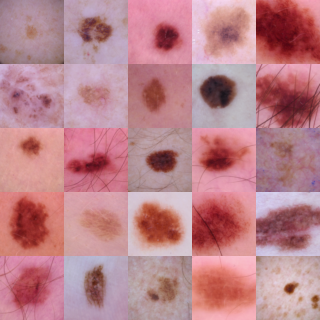

In [10]:
# view data
train_ds.montage(length=5)

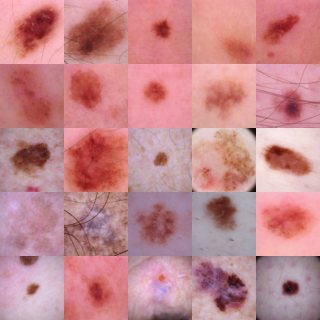

In [11]:
val_ds.montage(length=5)

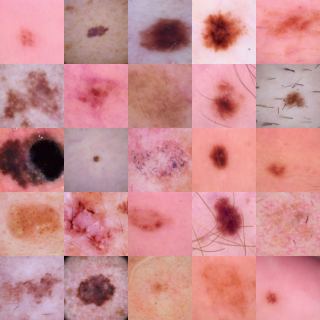

In [12]:
test_ds.montage(length=5)

In [13]:
x, y = train_ds[0]
print('raw type of x:', type(x))
print('raw type of y:', type(y))

raw type of x: <class 'PIL.Image.Image'>
raw type of y: <class 'numpy.ndarray'>


## Model Fitting

Here, I fit a basic initial model with the 64x64 images using ResNet-18 and ResNet-50

**AI Usage:** 

asked ChatGPT about difference between:

```python
model = resnet18(..., num_classes=num_classes)
```

and

```python
model = resnet18(...)
model.rs = nn.Linear(..., num_classes)
```

Asked ChatGPT to help me debug some errors with `run_epoch`.

Asked ChatGPT to bug check my code after I had written it but before I started training and to provide me any feedback.

In [14]:
# Models
num_classes = len(info['label'])
print('Number of Classes:', num_classes)

Number of Classes: 7


## Training

In [15]:
# transforms
basic_transform = Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

NUM_EPOCHS = 5
LEARNING_RATE = 1e-3

train_ds = DermaMNIST(split='train', download=DOWNLOAD, size=SIZE, mmap_mode='r', transform = basic_transform)
val_ds = DermaMNIST(split='val', download=DOWNLOAD, size=SIZE, transform=basic_transform)

# dataloaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


### ResNet 50

Here, I will try ResNet 50

Baseline model:

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 203MB/s] 
100%|██████████| 110/110 [00:04<00:00, 27.03it/s]


Epoch 0 | Train loss: 0.8074, acc: 0.715 | Val loss: 0.6951, acc: 0.754, macro AUC: 0.916


100%|██████████| 110/110 [00:03<00:00, 34.84it/s]


Epoch 1 | Train loss: 0.6583, acc: 0.760 | Val loss: 0.6748, acc: 0.768, macro AUC: 0.926


...

100%|██████████| 110/110 [00:03<00:00, 31.12it/s]


Epoch 3 | Train loss: 0.5216, acc: 0.814 | Val loss: 0.5962, acc: 0.773, macro AUC: 0.942


100%|██████████| 110/110 [00:03<00:00, 36.16it/s]


Epoch 4 | Train loss: 0.4943, acc: 0.819 | Val loss: 0.6975, acc: 0.749, macro AUC: 0.927
Final AUC:
0.9269360168699327
Final validation accuracy:
0.748753738783649


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

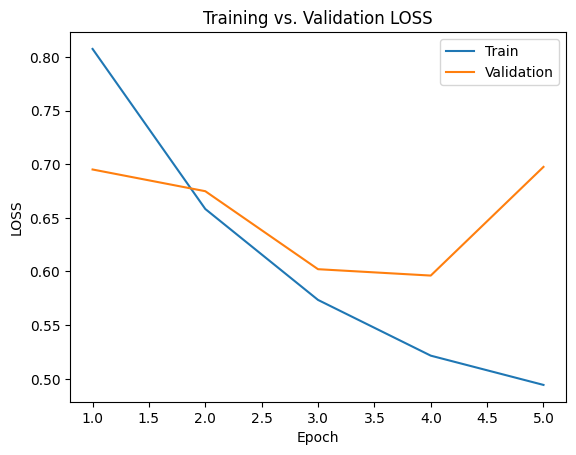

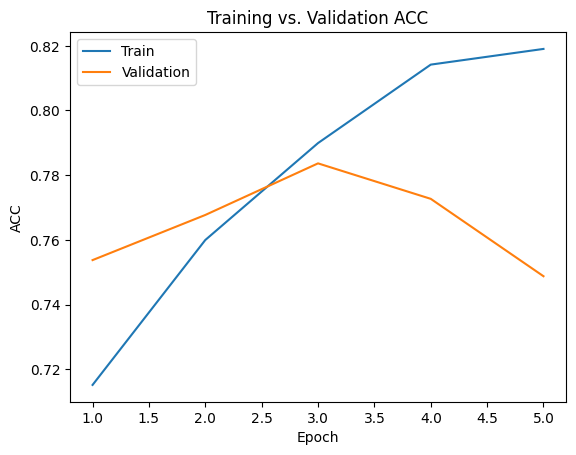

In [16]:
# basic model
NUM_EPOCHS = 5
LEARNING_RATE = 1e-3

train_ds = DermaMNIST(split='train', download=DOWNLOAD, size=SIZE, mmap_mode='r', transform = basic_transform)
val_ds = DermaMNIST(split='val', download=DOWNLOAD, size=SIZE, transform=basic_transform)

# dataloaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# initial model
model = h.resnet.create_resnet(size=50)

# freeze all layers except classifier
# for param in model.parameters():
#     param.requires_grad = False
# for param in model.fc.parameters():
#     param.requires_grad = True

train_history = h.train.train_model(
    model, 
    train_loader,
    val_loader,
    optimizer=torch.optim.Adam(model.parameters(), lr=LEARNING_RATE),
    criterion=nn.CrossEntropyLoss(),
    num_epochs=NUM_EPOCHS,
    device=device,
)

print("Final AUC:")
print(h.metrics.compute_auc_multiclass(model, val_loader, device))

print("Final validation accuracy:")
print(train_history['val_acc'][-1])
h.metrics.plot_train_hist(train_history, type='loss')
h.metrics.plot_train_hist(train_history, type='acc')

Better than the initial one for ResNet 18 by a little bit.

Let's try seeing how long until it overfits.

100%|██████████| 110/110 [00:03<00:00, 33.69it/s]


Epoch 0 | Train loss: 0.8439, acc: 0.708 | Val loss: 0.6809, acc: 0.765, macro AUC: 0.917


100%|██████████| 110/110 [00:03<00:00, 33.77it/s]


Epoch 1 | Train loss: 0.6457, acc: 0.762 | Val loss: 0.6463, acc: 0.783, macro AUC: 0.929


100%|██████████| 110/110 [00:03<00:00, 33.71it/s]


...

100%|██████████| 110/110 [00:03<00:00, 33.84it/s]


Epoch 28 | Train loss: 0.0372, acc: 0.988 | Val loss: 1.1891, acc: 0.757, macro AUC: 0.932


100%|██████████| 110/110 [00:03<00:00, 34.67it/s]


Epoch 29 | Train loss: 0.0406, acc: 0.987 | Val loss: 1.2822, acc: 0.758, macro AUC: 0.920
Final AUC:
0.9195166436915959
Final validation accuracy:
0.7577268195413759


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

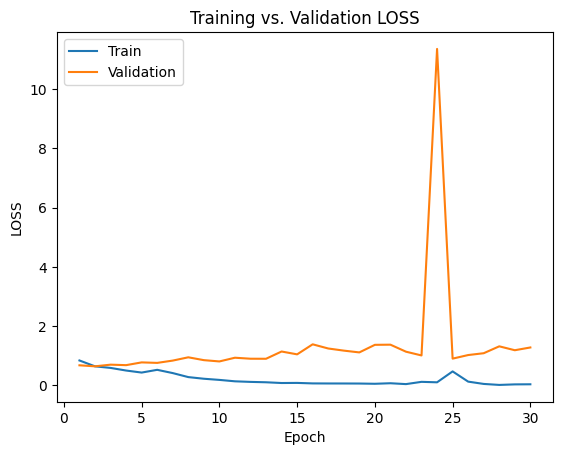

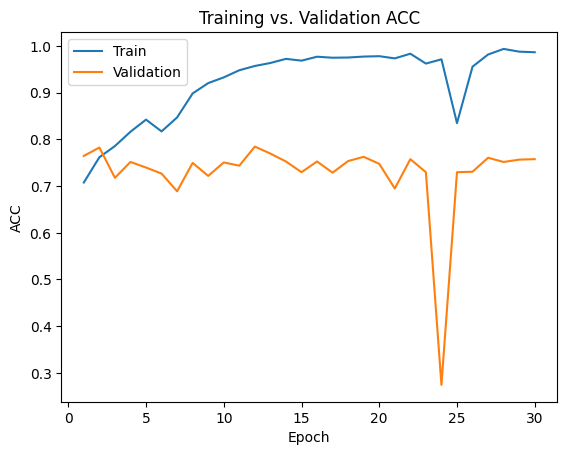

In [17]:
# longer epochs trained

NUM_EPOCHS = 30

model = h.resnet.create_resnet(size=50)

# freeze all layers except classifier
# for param in model.parameters():
#     param.requires_grad = False
# for param in model.fc.parameters():
#     param.requires_grad = True

train_history = h.train.train_model(
    model, 
    train_loader,
    val_loader,
    optimizer=torch.optim.Adam(model.parameters(), lr=LEARNING_RATE),
    criterion=nn.CrossEntropyLoss(),
    num_epochs=NUM_EPOCHS,
    device=device,
)

print("Final AUC:")
print(h.metrics.compute_auc_multiclass(model, val_loader, device))
print("Final validation accuracy:")
print(train_history['val_acc'][-1])
h.metrics.plot_train_hist(train_history, type='loss')
h.metrics.plot_train_hist(train_history, type='acc')

It looks like the loss and accuracy kind of plateau, with maybe slight overfitting at 50 epochs.

- train to 15 epochs (to still see overfitting if present, but not show too much)
- Apply data augmentation to see if we can improve model

**AI Usage:** I asked ChatGPT to suggest some data augmentations I can do for dermatoscope images. I also asked it to generate PyTorch code for the augmentations it suggested (in the variable `data_augmentation_1`). This code is used below. I also uploaded the sample images back to ChatGPT and asked it to refine the data augmentations in follow-up prompts.

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


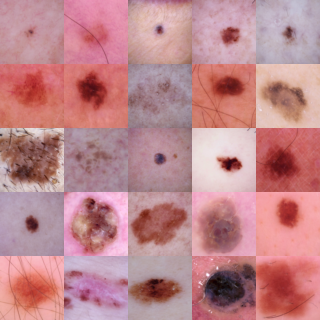

In [18]:
# data augmentations to test
data_augmentation_1 = [
    # --- Geometric transforms ---
    transforms.RandomRotation(
        degrees=180  # 0–180°; you can make it 360 if you want
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),

    # Small translation + zoom, no shear
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),     # up to 5% shift
        scale=(0.95, 1.05),         # milder zoom ±5%
        shear=0
    ),

    # Option 1: very mild crop (keep most of lesion)
    transforms.RandomResizedCrop(
        size=64,
        scale=(0.95, 1.0),          # only small crops
        ratio=(0.95, 1.05)
    ),
    # Option 2: if lesions are already centered, comment the above out

    # --- Photometric / color transforms ---
    transforms.ColorJitter(
        brightness=0.05,            # ±5%
        contrast=0.05,              # ±5%
        saturation=0.05,            # ±5%
        hue=0.01                    # very small hue shift
    ),

    # Mild Gaussian blur, lower prob & sigma for 64x64
    transforms.RandomApply(
        [transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5))],
        p=0.1
    ),

    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
]

train_ds = DermaMNIST(split='train', download=DOWNLOAD, size=SIZE, mmap_mode='r', transform = Compose(data_augmentation_1))
val_ds = DermaMNIST(split='val', download=DOWNLOAD, size=SIZE, transform=basic_transform)

# dataloaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

train_ds.montage(5)

100%|██████████| 110/110 [00:06<00:00, 16.76it/s]


Epoch 0 | Train loss: 0.8899, acc: 0.689 | Val loss: 0.8033, acc: 0.720, macro AUC: 0.897


100%|██████████| 110/110 [00:06<00:00, 16.29it/s]


Epoch 1 | Train loss: 0.7390, acc: 0.735 | Val loss: 0.6541, acc: 0.765, macro AUC: 0.919


100%|██████████| 110/110 [00:06<00:00, 16.93it/s]


...

100%|██████████| 110/110 [00:06<00:00, 16.67it/s]


Epoch 13 | Train loss: 0.5668, acc: 0.787 | Val loss: 0.6358, acc: 0.765, macro AUC: 0.934


100%|██████████| 110/110 [00:06<00:00, 16.77it/s]


Epoch 14 | Train loss: 0.5849, acc: 0.781 | Val loss: 0.9003, acc: 0.796, macro AUC: 0.918
Final AUC:
0.9175812641776997
Final validation accuracy:
0.7956131605184447


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

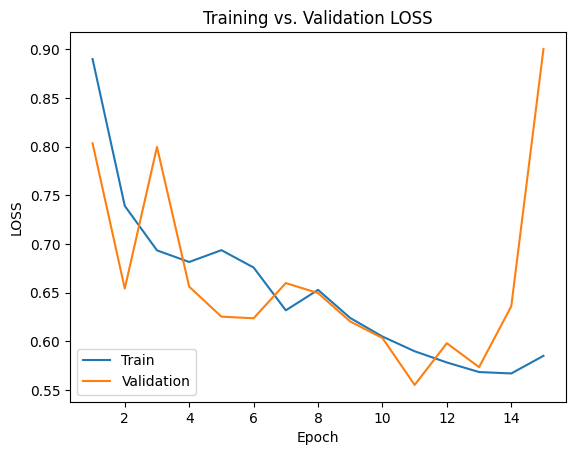

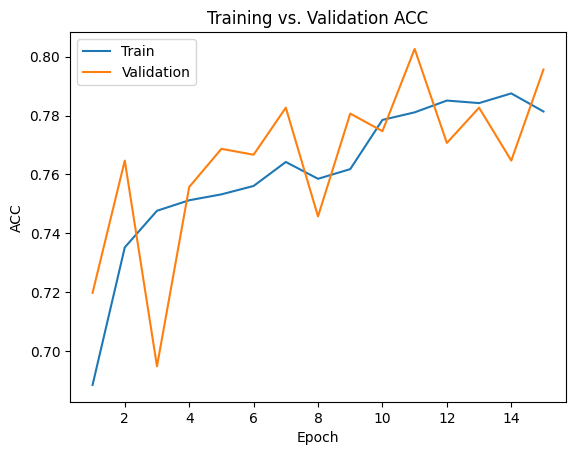

In [19]:
# data augmentations

NUM_EPOCHS = 15

model = h.resnet.create_resnet(size=50)

# freeze all layers except classifier
# for param in model.parameters():
#     param.requires_grad = False
# for param in model.fc.parameters():
#     param.requires_grad = True

train_history = h.train.train_model(
    model, 
    train_loader,
    val_loader,
    optimizer=torch.optim.Adam(model.parameters(), lr=LEARNING_RATE),
    criterion=nn.CrossEntropyLoss(),
    num_epochs=NUM_EPOCHS,
    device=device,
)

print("Final AUC:")
print(h.metrics.compute_auc_multiclass(model, val_loader, device))
print("Final validation accuracy:")
print(train_history['val_acc'][-1])
h.metrics.plot_train_hist(train_history, type='loss')
h.metrics.plot_train_hist(train_history, type='acc')